In [3]:
import sys

sys.path.append("../modules")

In [4]:
class MyArgs(object):
  def __init__(self):
    self.path_for_training_data = "../../data/ppb_affinity"
    self.path_for_outputs = "./test"
    self.previous_checkpoint = ""
    self.num_epochs = 30
    self.save_model_every_n_epochs = 5
    self.reload_data_every_n_epochs = 4
    self.num_examples_per_epoch = 200
    self.total_seq_length = 10000
    self.train_batch_size = 64
    self.val_batch_size = 5
    self.max_protein_length = 2000
    self.hidden_dim = 128
    self.num_encoder_layers = 3
    self.num_decoder_layers = 3
    self.num_neighbors = 48
    self.dropout = 0.1
    self.backbone_noise = 0.02
    self.rescut = 3.5
    self.debug = False
    self.gradient_norm = -1.0 #no norm
    self.mixed_precision= True 
    self.val_batch_copies = 8
    self.sample_temp = 1
    self.lambda_reward = 0.25

main_args = MyArgs()

In [5]:
import torch
import pickle
import pandas as pd
from pathlib import Path
from tqdm import tqdm

from custom_helpers.config import *
from custom_helpers.data_loading import chunk_df
from custom_helpers.sample_generation import  generate_samples
from custom_helpers.scoring import load_scoring_model, construct_mutated_dataset, score_mutated_dataset

from ProteinMPNN.protein_mpnn_utils import ProteinMPNN as ProteinMPNNVal

/home/ghandill/miniconda3/envs/fresh_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
split_type = "easy_split"

data_path_base = Path.cwd().parent / "data"
affinity_df = pd.read_csv(data_path_base / 'processed_data.csv', index_col=0)

test_set_df = affinity_df[affinity_df[split_type] == "test"]

device1 = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")
device2 = torch.device("cuda:1" if (torch.cuda.is_available()) else "cpu")
device3 = torch.device("cuda:2" if (torch.cuda.is_available()) else "cpu")

In [7]:
with open("cache/fixed_positions_cache.pkl", "rb") as f:
    fixed_positions_cache = pickle.load(f)

scoring_args = {
    "checkpoint_path": "/home/ghandill/masterthesis_lilit_ghandilyan/modules/PPB-Affinity-HF/checkpoints/checkpoint.pt",
    "device": device1,
}

scoring_model = load_scoring_model(scoring_args)

def score_subset(model, scoring_model, subset_df, device):
    subset_chunks = list(chunk_df(subset_df, 8))
    
    all_samples = []

    for _, chunk in tqdm(enumerate(subset_chunks), total=len(subset_chunks), desc="Scoring a subset"):
        samples, chunk_loss = generate_samples(model,
                                chunk,
                                device=device,
                                fixed_positions_cache=fixed_positions_cache,
                                args=main_args)
        
        all_samples.extend(samples)
    mutated_df = construct_mutated_dataset(subset_df, all_samples)
    return all_samples, score_mutated_dataset(mutated_df, scoring_model, scoring_args)

In [8]:
protein_mpnn = ProteinMPNNVal(node_features=main_args.hidden_dim, 
                    edge_features=main_args.hidden_dim, 
                    hidden_dim=main_args.hidden_dim, 
                    num_encoder_layers=main_args.num_encoder_layers, 
                    num_decoder_layers=main_args.num_encoder_layers, 
                    k_neighbors=main_args.num_neighbors, 
                    dropout=main_args.dropout, 
                    augment_eps=main_args.backbone_noise,
                    num_letters=21)
protein_mpnn.to(device2)

checkpoint_path = "../modules/ProteinMPNN/vanilla_model_weights/v_48_002.pt"
checkpoint = torch.load(checkpoint_path, map_location=device2)

protein_mpnn.load_state_dict(checkpoint['model_state_dict'])

protein_mpnn.eval()

ProteinMPNN(
  (features): ProteinFeatures(
    (embeddings): PositionalEncodings(
      (linear): Linear(in_features=66, out_features=16, bias=True)
    )
    (edge_embedding): Linear(in_features=416, out_features=128, bias=False)
    (norm_edges): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (W_e): Linear(in_features=128, out_features=128, bias=True)
  (W_s): Embedding(21, 128)
  (encoder_layers): ModuleList(
    (0-2): 3 x EncLayer(
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
      (dropout3): Dropout(p=0.1, inplace=False)
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (W1): Linear(in_features=384, out_features=128, bias=True)
      (W2): Linear(in_features=128, out_features=128, bias=True)
      (W3): Linear(in_features=128, out_features=128, bias=True)

In [ ]:
subset1_to_score = test_set_df.sample(32, random_state=1)
all_samples_proteinmpnn1, final_results_proteinmpnn1 = score_subset(protein_mpnn, scoring_model, subset1_to_score, device2)

subset2_to_score = test_set_df.sample(32, random_state=2)
all_samples_proteinmpnn2, final_results_proteinmpnn2 = score_subset(protein_mpnn, scoring_model, subset2_to_score, device2)

all_samples_proteinmpnn = all_samples_proteinmpnn1 + all_samples_proteinmpnn2

final_results_proteinmpnn = pd.concat(
    [final_results_proteinmpnn1, final_results_proteinmpnn2],
    axis=0,
    ignore_index=True
)

with open("final_samples/all_samples_protein_mpnn.pkl", "wb") as f:
    pickle.dump(all_samples_proteinmpnn, f)
final_results_proteinmpnn.to_csv("final_samples/final_results_proteinmpnn.csv", index=False)

Scoring a subset:  75%|███████▌  | 3/4 [00:53<00:17, 17.46s/it]

Original letter not corresponding to the mutation string.


Scoring a subset: 100%|██████████| 4/4 [01:13<00:00, 18.25s/it]
/home/ghandill/masterthesis_lilit_ghandilyan/src/custom_helpers/scoring.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match['mutstr'] = ",".join(construct_mutation_strings(sample))
Structures: 256it [00:36,  6.99it/s]
Scoring a subset: 100%|██████████| 4/4 [01:06<00:00, 16.57s/it]
/home/ghandill/masterthesis_lilit_ghandilyan/src/custom_helpers/scoring.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match['mutstr'] = ",".join(constru

In [15]:
my_model = ProteinMPNNVal(node_features=main_args.hidden_dim, 
                    edge_features=main_args.hidden_dim, 
                    hidden_dim=main_args.hidden_dim, 
                    num_encoder_layers=main_args.num_encoder_layers, 
                    num_decoder_layers=main_args.num_encoder_layers, 
                    k_neighbors=main_args.num_neighbors, 
                    dropout=main_args.dropout, 
                    augment_eps=main_args.backbone_noise,
                    num_letters=21)
my_model.to(device2)

checkpoint_path = "../src/model_weights/raml_final3/model_weights_15.pth"
checkpoint = torch.load(checkpoint_path, map_location=device2)

my_model.load_state_dict(checkpoint)

my_model.eval()

ProteinMPNN(
  (features): ProteinFeatures(
    (embeddings): PositionalEncodings(
      (linear): Linear(in_features=66, out_features=16, bias=True)
    )
    (edge_embedding): Linear(in_features=416, out_features=128, bias=False)
    (norm_edges): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (W_e): Linear(in_features=128, out_features=128, bias=True)
  (W_s): Embedding(21, 128)
  (encoder_layers): ModuleList(
    (0-2): 3 x EncLayer(
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
      (dropout3): Dropout(p=0.1, inplace=False)
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (W1): Linear(in_features=384, out_features=128, bias=True)
      (W2): Linear(in_features=128, out_features=128, bias=True)
      (W3): Linear(in_features=128, out_features=128, bias=True)

In [16]:
subset1_to_score = test_set_df.sample(32, random_state=1)
all_samples_my_model1, final_results_my_model1 = score_subset(my_model, scoring_model, subset1_to_score, device2)

subset2_to_score = test_set_df.sample(32, random_state=2)
all_samples_my_model2, final_results_my_model2 = score_subset(my_model, scoring_model, subset2_to_score, device2)

all_samples_my_model = all_samples_my_model1 + all_samples_my_model2

final_results_my_model = pd.concat(
    [final_results_my_model1, final_results_my_model2],
    axis=0,
    ignore_index=True
)

Scoring a subset:  75%|███████▌  | 3/4 [01:02<00:19, 19.63s/it]

Original letter not corresponding to the mutation string.


Scoring a subset: 100%|██████████| 4/4 [01:20<00:00, 20.21s/it]
/home/ghandill/masterthesis_lilit_ghandilyan/src/custom_helpers/scoring.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match['mutstr'] = ",".join(construct_mutation_strings(sample))
Structures: 256it [00:33,  7.65it/s]
Scoring a subset: 100%|██████████| 4/4 [01:20<00:00, 20.10s/it]
/home/ghandill/masterthesis_lilit_ghandilyan/src/custom_helpers/scoring.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  match['mutstr'] = ",".join(constru

In [ ]:
with open("final_samples/all_samples_raml3.pkl", "wb") as f:
    pickle.dump(all_samples_my_model, f)

final_results_my_model.to_csv("final_samples/final_results_raml3.csv", index=False)

Number of complexes: 62
My model mean score: -9.839
ProteinMPNN mean score: -9.457
Mean improvement: -0.382

Shapiro-Wilk test for normality: p = 0.0000

Wilcoxon signed-rank test: p = 0.0000
✓ Improvement is statistically significant (p < 0.05)


/tmp/ipykernel_352603/2932595266.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([proteinmpnn_scores, my_model_scores],



Plot saved as 'statistical_comparison.png'


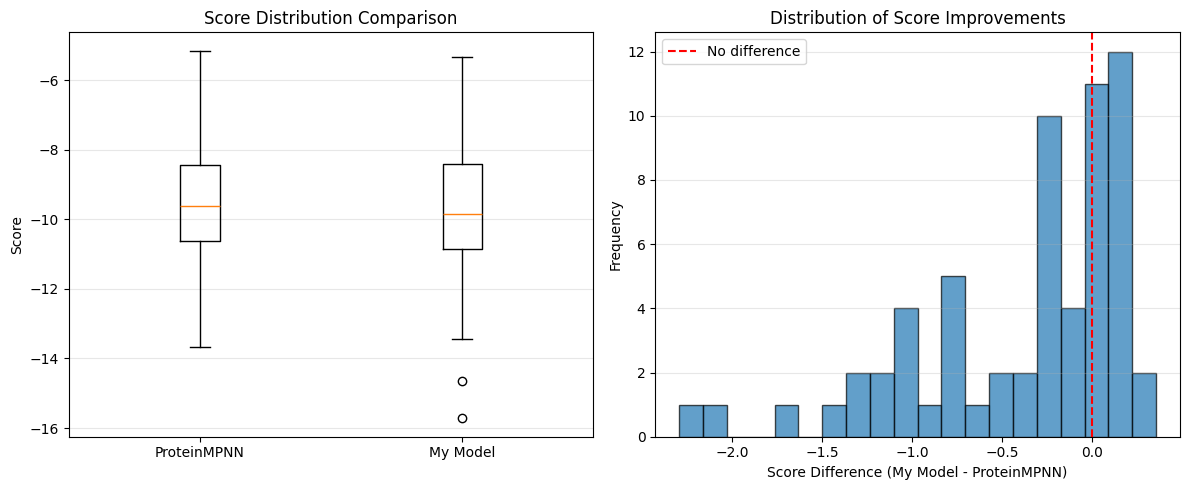

In [45]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data
df_my_model = final_results_my_model
df_proteinmpnn = final_results_proteinmpnn

# Group by complex_id and calculate mean score for each complex
my_model_scores = df_my_model.groupby('complex_id')['dG_pred'].mean()
proteinmpnn_scores = df_proteinmpnn.groupby('complex_id')['dG_pred'].mean()

# Align the complex_ids (in case they're not in same order)
common_ids = my_model_scores.index.intersection(proteinmpnn_scores.index)
my_model_scores = my_model_scores[common_ids]
proteinmpnn_scores = proteinmpnn_scores[common_ids]

print(f"Number of complexes: {len(common_ids)}")
print(f"My model mean score: {my_model_scores.mean():.3f}")
print(f"ProteinMPNN mean score: {proteinmpnn_scores.mean():.3f}")
print(f"Mean improvement: {my_model_scores.mean() - proteinmpnn_scores.mean():.3f}")

# Check for normality
_, p_norm = shapiro(my_model_scores - proteinmpnn_scores)
print(f"\nShapiro-Wilk test for normality: p = {p_norm:.4f}")

# Run paired statistical test
# Use Wilcoxon (non-parametric) - safer choice for most cases
statistic, p_value = wilcoxon(my_model_scores, proteinmpnn_scores)
print(f"\nWilcoxon signed-rank test: p = {p_value:.4f}")
if p_value < 0.05:
    print("✓ Improvement is statistically significant (p < 0.05)")
else:
    print("✗ Improvement is NOT statistically significant (p >= 0.05)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot comparison
axes[0].boxplot([proteinmpnn_scores, my_model_scores], 
                labels=['ProteinMPNN', 'My Model'])
axes[0].set_ylabel('Score')
axes[0].set_title('Score Distribution Comparison')
axes[0].grid(axis='y', alpha=0.3)

# Paired differences
differences = my_model_scores - proteinmpnn_scores
axes[1].hist(differences, bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', label='No difference')
axes[1].set_xlabel('Score Difference (My Model - ProteinMPNN)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Score Improvements')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('statistical_comparison.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as 'statistical_comparison.png'")

Sequence Recovery Results:

Your Model:
  Mean recovery: 94.4%
  Std: 7.2%
  Range: 37.5% - 100.0%

ProteinMPNN:
  Mean recovery: 90.5%
  Std: 6.3%
  Range: 37.5% - 97.5%

✓ Recovery looks reasonable

Plot saved as 'sequence_recovery.png'


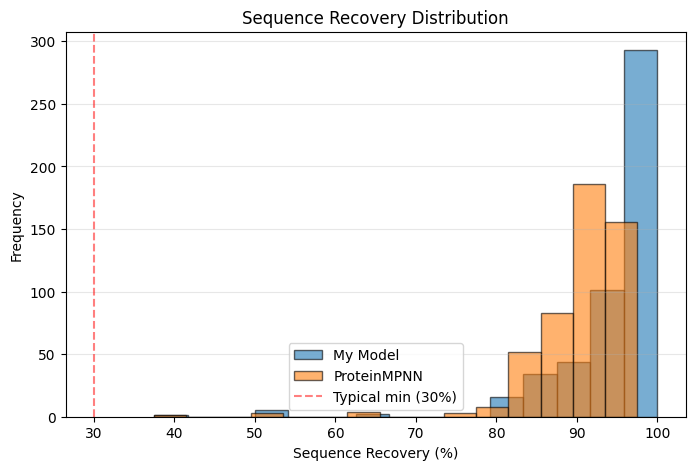

In [32]:
import pandas as pd
import numpy as np

def calculate_sequence_recovery(native_seq, designed_seq):
    """Calculate % of positions where designed matches native"""
    if len(native_seq) != len(designed_seq):
        raise ValueError("Sequences must be same length")
    
    if len(native_seq) == 0:
        return None
    
    matches = sum(n == d for n, d in zip(native_seq, designed_seq))
    recovery = matches / len(native_seq) * 100
    return recovery

# Calculate recovery for your model
my_model_recovery = []
for sample in all_samples_my_model:
    rec = calculate_sequence_recovery(sample['native_seq'], 
                                      sample['sample_seq'])

    if rec is not None: 
        my_model_recovery.append(rec)

# df_my_model['recovery'] = my_model_recovery

# Calculate recovery for ProteinMPNN
proteinmpnn_recovery = []
for sample in all_samples_proteinmpnn:
    rec = calculate_sequence_recovery(sample['native_seq'], 
                                      sample['sample_seq'])

    if rec is not None: 
        proteinmpnn_recovery.append(rec)

# df_proteinmpnn['recovery'] = proteinmpnn_recovery

# Summary statistics
print("Sequence Recovery Results:")
print(f"\nYour Model:")
print(f"  Mean recovery: {np.mean(my_model_recovery):.1f}%")
print(f"  Std: {np.std(my_model_recovery):.1f}%")
print(f"  Range: {np.min(my_model_recovery):.1f}% - {np.max(my_model_recovery):.1f}%")

print(f"\nProteinMPNN:")
print(f"  Mean recovery: {np.mean(proteinmpnn_recovery):.1f}%")
print(f"  Std: {np.std(proteinmpnn_recovery):.1f}%")
print(f"  Range: {np.min(proteinmpnn_recovery):.1f}% - {np.max(proteinmpnn_recovery):.1f}%")

# Expected: 30-50% for full protein, could be lower for interface-only
if np.mean(my_model_recovery) > 20:
    print("\n✓ Recovery looks reasonable")
else:
    print("\n⚠ Warning: Recovery is quite low - model might be generating unrealistic sequences")

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(my_model_recovery, bins=15, alpha=0.6, label='My Model', edgecolor='black')
plt.hist(proteinmpnn_recovery, bins=15, alpha=0.6, label='ProteinMPNN', edgecolor='black')
plt.axvline(30, color='red', linestyle='--', alpha=0.5, label='Typical min (30%)')
plt.xlabel('Sequence Recovery (%)')
plt.ylabel('Frequency')
plt.title('Sequence Recovery Distribution')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('sequence_recovery.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as 'sequence_recovery.png'")

Interface-Only Sequence Recovery Results:

Your Model:
  Mean recovery: 77.1%
  Std: 15.4%
  Range: 33.3% - 100.0%

ProteinMPNN:
  Mean recovery: 56.1%
  Std: 10.2%
  Range: 30.4% - 82.4%

--- Interpretation ---
⚠ Interface recovery is high (>60%)
  Models may be too conservative in redesigning


/tmp/ipykernel_352603/3710777752.py:105: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([proteinmpnn_recovery, my_model_recovery],



Plot saved as 'interface_recovery.png'


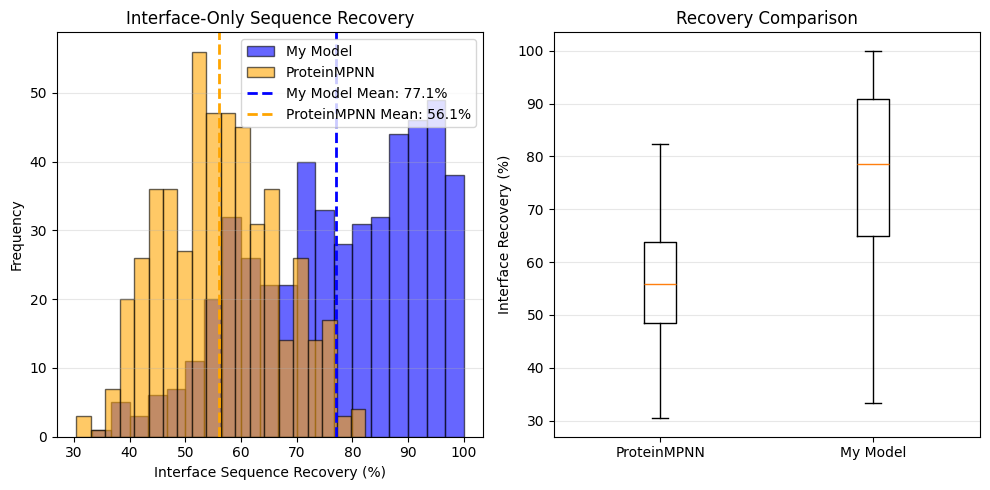

In [33]:
import numpy as np

def calculate_interface_recovery(all_samples, fixed_positions_cache):
    """
    Calculate sequence recovery only at redesigned (non-fixed) positions
    """
    recovery_scores = []
    
    for sample_data in all_samples:
        protein_id = sample_data['protein_id']
        
        # Get sequences
        native_seq = sample_data['native_seq']
        sample_seq = sample_data['sample_seq']
        designed_chains = sample_data['designed_chains']
        
        # Split by chains
        native_chains = native_seq.split('/')
        sample_chains = sample_seq.split('/')
        
        # Get fixed positions for this complex
        fixed_positions = fixed_positions_cache.get(protein_id, {})
        
        # Track matches and total redesigned positions
        total_redesigned = 0
        matches = 0
        
        # Go through each chain
        for chain_idx, chain_name in enumerate(designed_chains):
            if chain_idx >= len(native_chains) or chain_idx >= len(sample_chains):
                continue
                
            native_chain_seq = native_chains[chain_idx]
            sample_chain_seq = sample_chains[chain_idx]
            
            # Get fixed positions for this chain
            chain_fixed = fixed_positions.get(chain_name, [])
            
            # Check each position in the chain
            for pos in range(len(native_chain_seq)):
                # Skip if this position is fixed
                if pos in chain_fixed:
                    continue
                
                # This is a redesigned position
                total_redesigned += 1
                
                # Check if it matches native
                if pos < len(sample_chain_seq) and native_chain_seq[pos] == sample_chain_seq[pos]:
                    matches += 1
        
        # Calculate recovery for this sample
        if total_redesigned > 0:
            recovery = (matches / total_redesigned) * 100
            recovery_scores.append(recovery)
    
    return recovery_scores

# Calculate for both models
my_model_recovery = calculate_interface_recovery(all_samples_my_model, fixed_positions_cache)
proteinmpnn_recovery = calculate_interface_recovery(all_samples_proteinmpnn, fixed_positions_cache)

# Print results
print("Interface-Only Sequence Recovery Results:")
print(f"\nYour Model:")
print(f"  Mean recovery: {np.mean(my_model_recovery):.1f}%")
print(f"  Std: {np.std(my_model_recovery):.1f}%")
print(f"  Range: {np.min(my_model_recovery):.1f}% - {np.max(my_model_recovery):.1f}%")

print(f"\nProteinMPNN:")
print(f"  Mean recovery: {np.mean(proteinmpnn_recovery):.1f}%")
print(f"  Std: {np.std(proteinmpnn_recovery):.1f}%")
print(f"  Range: {np.min(proteinmpnn_recovery):.1f}% - {np.max(proteinmpnn_recovery):.1f}%")

# Interpretation
print("\n--- Interpretation ---")
if 20 <= np.mean(my_model_recovery) <= 60:
    print("✓ Interface recovery is in the expected range (20-60%)")
    print("  Your model is exploring sequence space appropriately")
else:
    if np.mean(my_model_recovery) > 60:
        print("⚠ Interface recovery is high (>60%)")
        print("  Models may be too conservative in redesigning")
    else:
        print("⚠ Interface recovery is low (<20%)")
        print("  Models may be generating very divergent sequences")

# Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(my_model_recovery, bins=20, alpha=0.6, label='My Model', edgecolor='black', color='blue')
plt.hist(proteinmpnn_recovery, bins=20, alpha=0.6, label='ProteinMPNN', edgecolor='black', color='orange')
plt.axvline(np.mean(my_model_recovery), color='blue', linestyle='--', linewidth=2, label=f'My Model Mean: {np.mean(my_model_recovery):.1f}%')
plt.axvline(np.mean(proteinmpnn_recovery), color='orange', linestyle='--', linewidth=2, label=f'ProteinMPNN Mean: {np.mean(proteinmpnn_recovery):.1f}%')
plt.xlabel('Interface Sequence Recovery (%)')
plt.ylabel('Frequency')
plt.title('Interface-Only Sequence Recovery')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([proteinmpnn_recovery, my_model_recovery], 
            labels=['ProteinMPNN', 'My Model'])
plt.ylabel('Interface Recovery (%)')
plt.title('Recovery Comparison')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('interface_recovery.png', dpi=300, bbox_inches='tight')
print("\nPlot saved as 'interface_recovery.png'")